# Bab 2: Ekosistem Paket & Sains Data Python

**Awd Course**

Modul Bab 2: Pip, NumPy, Pandas, Matplotlib, Seaborn, Impor/Ekspor CSV, dan Latihan Inventaris.

---


# Memahami Package Python, Pip, dan Virtual Environment

Saat mulai belajar pemrograman, ada satu pertanyaan yang sangat wajar muncul:
> *"Kenapa kita harus menggunakan package atau library buatan orang lain? Kenapa tidak kita buat sendiri saja semuanya secara manual dari nol?"*

Jawabannya sederhana: **efisiensi dan fokus pada solusi**.

Bayangkan Anda ingin membuat kue bolu. Apakah Anda harus menanam gandum sendiri, menggilingnya jadi tepung, dan membuat oven sendiri dari tanah liat? Tentu tidak. Anda cukup membeli tepung yang sudah jadi di toko, memakai oven yang sudah teruji keamanannya, lalu fokus meracik resep kue yang lezat.

### Analogi di Dunia Pemrograman Nyata

Di dunia pemrograman, prinsipnya persis sama:
* Jika Anda ingin mengambil data dari internet (*HTTP request*), membuat kodenya sendiri secara manual dari nol berarti Anda harus menulis protokol jaringan TCP/IP, negosiasi sertifikat enkripsi SSL/TLS, dan parsing data biner tingkat rendah. Itu butuh ribuan baris kode rumit dan rawan salah.
* Dengan bantuan package seperti `requests`, tugas serumit itu bisa selesai hanya dengan **dua baris kode** yang rapi dan aman.

Komunitas Python adalah salah satu komunitas teknologi terbesar di dunia. Ribuan pengembang dan ilmuwan telah membuat solusi siap pakai untuk hampir semua kebutuhan—mulai dari analisis data, manipulasi spreadsheet, pembuatan grafik, hingga kecerdasan buatan. Pustaka-pustaka ini dikumpulkan di gudang resmi bernama **PyPI** (*Python Package Index*).

Tugas kita sebagai pemrogram atau praktisi data bukanlah membuat ulang hal-hal dasar yang sudah ada (*reinventing the wheel*), melainkan memanfaatkan perkakas yang sudah matang ini untuk menyelesaikan masalah nyata.

## 1. Mengenal Pip dan Konsep Virtual Environment (venv)

Untuk mengunduh dan memasang package dari PyPI ke komputer kita, Python menyediakan alat bawaan resmi bernama **pip** (*Package Installer for Python*).

Namun sebelum mulai menginstal paket ke mana-mana, ada satu konsep penting yang wajib Anda pahami sejak awal: **Virtual Environment (`venv`)**.

### Kenapa Kita Butuh Isolasi Lingkungan?
Bayangkan skenario nyata di laptop Anda:
1. Bulan lalu, Anda membuat **Proyek A** yang membutuhkan library `pandas` versi 1.5.
2. Hari ini, Anda membuat **Proyek B** yang membutuhkan fitur terbaru di `pandas` versi 2.2.

Jika Anda langsung memasang semua package secara global di sistem laptop, proses meng-upgrade `pandas` ke versi 2.2 demi Proyek B berisiko membuat Proyek A tiba-tiba rusak dan tidak bisa dijalankan (*dependency conflict*).

Solusinya adalah membuat **Virtual Environment (`venv`)**. Lingkungan virtual ini ibarat membuat "kamar terpisah" untuk setiap proyek:
* **Proyek A** memiliki kamar sendiri dengan `pandas 1.5`.
* **Proyek B** memiliki kamar sendiri dengan `pandas 2.2`.
Keduanya berjalan lancar tanpa saling mengganggu.

### Cara Menggunakan `venv` di Terminal Komputer Anda

Saat membuat proyek Python di komputer lokal (misalnya di VS Code), berikut langkah praktisnya:

1. **Membuat lingkungan virtual** (cukup sekali di folder proyek):
```bash
python -m venv env_belajar
```

2. **Mengaktifkan lingkungan virtual**:
* Di Windows (Command Prompt / PowerShell):
```bash
env_belajar\Scripts\activate
```
* Di macOS atau Linux:
```bash
source env_belajar/bin/activate
```
*(Tanda aktif: nama `(env_belajar)` akan muncul di awal baris prompt terminal Anda).*

3. **Memasang paket di dalam lingkungan tersebut**:
```bash
pip install requests pandas
```

4. **Menonaktifkan jika sudah selesai**:
```bash
deactivate
```

> **Catatan Notebook**: Di lingkungan notebook daring (seperti Google Colab atau sesi interaktif ini), sistem sudah mengisolasi lingkungan secara otomatis untuk setiap sesi. Namun, konsep `venv` ini wajib Anda pahami saat nanti berkarya di komputer lokal Anda sendiri.

## 2. Memeriksa Versi Pip dan Daftar Paket yang Terpasang

Kita bisa memeriksa versi `pip` serta melihat daftar paket apa saja yang sudah terpasang menggunakan tanda seru `!` di depan perintah terminal.

In [1]:
! pip --version
! pip list | head -n 10

pip 24.1.2 from /usr/local/lib/python3.13/dist-packages/pip (python 3.13)
Package                               Version
------------------------------------- ------------------
absl-py                               1.4.0
accelerate                            1.14.0
access                                1.1.10.post3
affine                                3.0.1
aiofiles                              25.1.0
aiohappyeyeballs                      2.7.1
aiohttp                               3.14.3
aiosignal                             1.4.0


## 3. Memasang Paket Baru dengan `pip install`

Untuk memasang pustaka baru dari PyPI, gunakan perintah `pip install <nama_paket>`. Sebagai contoh, kita akan memasang pustaka populer `requests` yang digunakan untuk berkomunikasi dengan web server atau API.

In [2]:
! pip install requests

## 4. Menggunakan Paket yang Telah Terpasang

Setelah dipasang, kita cukup memanggil nama paketnya menggunakan kata kunci `import` dan mulai memanfaatkan fungsinya.

In [3]:
import requests

# Mengambil data status dari API publik GitHub
response = requests.get('https://api.github.com')

print("Status Code:", response.status_code)
print("Server:", response.headers.get('server'))

Status Code: 200
Server: github.com


## 5. Memahami Pola Impor di Python (Import Patterns)

Setelah sebuah pustaka terpasang, bagaimana cara terbaik memanggilnya di dalam kode program kita? Python menyediakan beberapa gaya impor yang bisa disesuaikan dengan kebutuhan:

### 1. Impor Standar: `import nama_modul`
Memuat seluruh modul ke dalam program. Untuk memanggil fungsinya, kita tulis nama modulnya di depan: `math.sqrt()` atau `requests.get()`.
* **Kelebihan**: Sangat jelas dan aman. Kita selalu tahu persis fungsi tersebut berasal dari modul mana, sehingga tidak ada risiko salah panggil.

### 2. Impor dengan Alias (Nama Panggilan): `import nama_modul as alias`
Memberikan nama panggilan singkat agar kita tidak capek mengetik berulang-ulang.
* Di dunia analisis data, komunitas sudah menyepakati singkatan standar yang dipakai di seluruh dunia:
  * `import numpy as np`
  * `import pandas as pd`
  * `import matplotlib.pyplot as plt`
  * `import seaborn as sns`

### 3. Impor Fungsi Tertentu Saja: `from nama_modul import fungsi`
Hanya mengambil fungsi atau kelas spesifik yang kita perlukan langsung ke ruang kerja program.
* **Kelebihan**: Ringkas karena bisa langsung dipanggil tanpa awalan nama modul, misalnya langsung `sqrt(64)` alih-alih `math.sqrt(64)`.

### 4. Impor Submodul: `from paket.subpaket import modul`
Digunakan jika pustaka yang kita gunakan berukuran besar dan memiliki folder atau bagian bertingkat di dalamnya, contohnya `from urllib.parse import urlparse`.

### 5. Hindari Impor Wildcard: `from nama_modul import *`

Mengambil seluruh isi modul sekaligus tanpa awalan nama modul adalah kebiasaan yang sebaiknya dihindari (*bad practice*).

* **Kenapa harus dihindari?** Seperti mengundang ratusan orang asing masuk ke dalam rumah Anda sekaligus. Berisiko terjadi tabrakan nama (*name collision*).
* Misalnya, ada fungsi bawaan Python seperti `sum()`, `min()`, atau `open()` yang tidak sengaja tertimpa oleh fungsi dari modul luar, sehingga program Anda menghasilkan error aneh yang sangat sulit dicari penyebabnya.

### Standar Rapi Penulisan Impor (PEP 8)

Agar kodingan Anda rapi dan mudah dibaca oleh programmer lain:
1. Letakkan seluruh baris `import` di bagian paling atas berkas kode.
2. Kelompokkan menjadi 3 blok yang dipisahkan oleh satu baris kosong:
   * **Pustaka Bawaan Python** (*Standard Library*): `os`, `sys`, `math`, `datetime`
   * **Pustaka Pihak Ketiga** (hasil pasang dari pip): `requests`, `numpy`, `pandas`
   * **Modul Buatan Sendiri** di folder proyek lokal Anda

In [4]:
# 1. Impor standar
import math
print("Akar dari 64 (math.sqrt):", math.sqrt(64))

# 2. Impor dengan alias singkatan
import math as m
print("Pembulatan ke atas (m.ceil):", m.ceil(7.2))

# 3. Impor fungsi spesifik yang dibutuhkan saja
from math import pow, gcd
print("Pemangkatan 2 pangkat 6 (pow):", pow(2, 6))
print("FPB dari 48 dan 180 (gcd):", gcd(48, 180))

# 4. Impor submodul dari paket bertingkat
from urllib.parse import urlparse
parsed = urlparse("https://course.awd.my.id/courses/python-data-science")
print("Domain URL (urlparse):", parsed.netloc)

Akar dari 64 (math.sqrt): 8.0
Pembulatan ke atas (m.ceil): 8
Pemangkatan 2 pangkat 6 (pow): 64.0
FPB dari 48 dan 180 (gcd): 12
Domain URL (urlparse): course.awd.my.id


## 6. Memeriksa Informasi Detail Paket (`pip show`)

Jika Anda ingin melihat siapa pembuat paket tersebut, versi berapa yang sedang aktif, di mana lokasinya di komputer, dan paket apa saja yang menjadi syaratnya, gunakan perintah `pip show <nama_paket>`.

In [5]:
! pip show requests

Name: requests
Version: 2.32.4
Summary: Python HTTP for Humans.
Home-page: https://requests.readthedocs.io
Author: Kenneth Reitz
License: Apache-2.0
Location: /usr/local/lib/python3.13/dist-packages
Requires: certifi, charset_normalizer, idna, urllib3


## 7. Membedah Isi Paket: `help()`, `dir()`, dan `inspect`

Python menyediakan alat bantu bawaan yang sangat berguna untuk mencari tahu fungsi apa saja yang tersedia di dalam sebuah library tanpa harus membuka browser:

* `help(modul.fungsi)`: Membaca buku petunjuk resmi (*docstring*), cara penggunaan, dan penjelasan parameter fungsi.
* `dir(modul)`: Mengintip daftar seluruh fungsi, kelas, dan variabel yang ada di dalam modul.
* `inspect.signature(fungsi)`: Cara cepat melihat parameter apa saja yang dibutuhkan fungsi tanpa perlu membaca penjelasan panjang.

In [6]:
import inspect
import requests

# Mengintip daftar fungsi utama yang ada di requests
fungsi_requests = [f for f in dir(requests) if not f.startswith('_') and f in ['get', 'post', 'put', 'head', 'request', 'Session', 'Response', 'ConnectionError', 'ConnectTimeout']]
print("Contoh fungsi/kelas yang ada di dalam modul requests:")
print(sorted(fungsi_requests))

# Melihat struktur parameter fungsi requests.get secara ringkas
print("\nParameter fungsi requests.get:")
print(inspect.signature(requests.get))

Contoh fungsi/kelas yang ada di dalam modul requests:
['ConnectTimeout', 'ConnectionError', 'Response', 'Session', 'get', 'head', 'post', 'put', 'request']

Parameter fungsi requests.get:
(url, params=None, **kwargs)


## 8. Menghapus (Uninstall) Paket

Jika sebuah pustaka sudah tidak lagi digunakan atau ingin diganti dengan versi lain, kita bisa mencopotnya dengan perintah `pip uninstall <nama_paket>`.

Tambahkan opsi `-y` agar proses pencopotan langsung dieksekusi tanpa perlu menunggu Anda menekan tombol konfirmasi manual di terminal.

In [7]:
# Menghapus pustaka requests
! pip uninstall requests -y

Found existing installation: requests 2.32.4
Uninstalling requests-2.32.4:
  Successfully uninstalled requests-2.32.4


### Memasang Kembali Pustaka
Setelah mencoba proses uninstal, pasang kembali paket `requests` agar siap digunakan untuk materi-materi praktik berikutnya.

In [8]:
# Memasang kembali pustaka requests
! pip install requests

## 9. Mengenal Alternatif Manajer Paket Selain Pip

Di dunia industri dan riset data science, Anda mungkin akan sering mendengar alat-alat selain `pip`. Mengapa orang membuat alternatif lain jika `pip` sudah ada?

Alasannya adalah setiap alat dirancang untuk memecahkan tantangan yang berbeda:

### 1. Conda / Mamba (Paling Populer di Sains Data & AI)
* `pip` hanya mengurus paket Python murni. Jika Anda butuh pustaka biner non-Python tingkat rendah (seperti driver CUDA untuk kartu grafis GPU, pustaka matematika C++, atau Fortran), mengompilasinya lewat pip di komputer pribadi sering kali gagal karena butuh compiler bawaan sistem.
* **Conda** mengurus semuanya: baik paket Python, pustaka biner sistem, driver GPU, hingga versi interpreter Python itu sendiri. Sangat disukai praktisi Machine Learning, Computer Vision, dan Deep Learning.
* **Mamba** adalah varian Conda yang ditulis ulang menggunakan bahasa C++ agar proses pencarian paket dan instalasinya jauh lebih cepat.

### 2. Poetry (Standar Pengembangan Aplikasi & Tim Software Engineer)
* Pada proyek aplikasi berskala besar (seperti membuat backend web dengan FastAPI atau Django), sangat krusial memastikan versi paket yang dipakai di laptop pengembang sama persis hingga ke sub-dependensi terkecil dengan yang ada di server produksi.
* Poetry menggunakan berkas pengunci bernama `poetry.lock`. Berkas ini memastikan tidak ada kasus "di laptop saya jalan normal, tapi di server kantor malah error". Poetry juga otomatis membuat dan mengelola lingkungan virtual (`venv`) tanpa perlu perintah manual.

### 3. uv (Generasi Terbaru Berkecepatan Sangat Tinggi)
* Dikembangkan menggunakan bahasa pemrograman Rust oleh tim Astral.
* Keunggulan utamanya adalah **kecepatan**: proses instalasi paket bisa 10 hingga 100 kali lebih cepat dibanding pip biasa.
* Format perintahnya dibuat mirip dengan pip (`uv pip install`), sehingga mulai banyak digunakan pada sistem otomatisasi modern (CI/CD).

### Panduan Praktis: Kapan Harus Memakai yang Mana?

| Kebutuhan Proyek | Alat Rekomendasi | Alasan Utama |
|---|---|---|
| **Belajar Dasar & Scripting** | `pip` | Bawaan resmi Python, langsung pakai tanpa konfigurasi tambahan. |
| **Sains Data & AI / GPU** | `Conda` / `Mamba` | Mengurus driver GPU (CUDA) dan pustaka biner non-Python secara otomatis. |
| **Aplikasi Web & Tim Developer** | `Poetry` | Ada `poetry.lock`, versi paket dijamin konsisten antara laptop dan server. |
| **Kecepatan Maksimal (CI/CD)** | `uv` | Berbasis Rust, proses download dan instalasi paket 10-100x lebih cepat. |

# Pengenalan & Komputasi Array NumPy

Pernahkah Anda bertanya:
> *"Python kan sudah punya tipe data List untuk menyimpan banyak data sekaligus. Kenapa kita masih butuh NumPy?"*

Jawabannya ada pada **kecepatan komputasi** dan **efisiensi memori**.

**List bawaan Python** dirancang sangat fleksibel—ia bisa menyimpan angka, teks, dan boolean dalam satu wadah. Namun karena terlalu fleksibel, komputer harus menyimpan setiap elemen di lokasi memori yang terpisah-pisah (*pointer heap*). Ketika data Anda berjumlah jutaan baris, melakukan perhitungan matematika dengan List akan terasa sangat lambat.

Di sinilah **NumPy** (*Numerical Python*) hadir. NumPy menyimpan data bertipe seragam (*homogeneous*) secara berurutan di dalam satu blok memori komputer yang padat (*contiguous array*). NumPy ditulis menggunakan bahasa C, sehingga kalkulasi matematikanya dijalankan langsung di tingkat perangkat keras (*hardware level*) dengan kecepatan hingga puluhan kali lebih cepat dibanding List biasa.

## 1. Memasang Pustaka NumPy

Sebelum menggunakan NumPy, pastikan pustaka ini sudah terpasang. Di Google Colab pustaka ini sudah tersedia, tetapi di laptop lokal Anda bisa memasangnya lewat perintah pip:

In [1]:
! pip install numpy


[notice] A new release of pip available: 22.2.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Bukti Nyata: Uji Kecepatan (List vs NumPy Array)

Mari kita buktikan klaim kecepatannya dengan mengalikan **1 juta angka** menggunakan List biasa dibandingkan dengan NumPy Array:

In [2]:
import numpy as np
import time

# Menyiapkan 1 juta data angka
jumlah_data = 1_000_000
list_python = list(range(jumlah_data))
array_numpy = np.arange(jumlah_data)

# Uji kecepatan Python List biasa
waktu_mulai = time.time()
hasil_list = [x * 2 for x in list_python]
durasi_list = time.time() - waktu_mulai

# Uji kecepatan NumPy Array
waktu_mulai = time.time()
hasil_numpy = array_numpy * 2
durasi_numpy = time.time() - waktu_mulai

print(f"Waktu Python List : {durasi_list:.4f} detik")
print(f"Waktu NumPy Array : {durasi_numpy:.4f} detik")
print(f"Hasil: NumPy sekitar {durasi_list / durasi_numpy:.1f}x lebih cepat!")

Waktu Python List : 0.0802 detik
Waktu NumPy Array : 0.0047 detik
Hasil: NumPy sekitar 17.0x lebih cepat!


## 3. Membuat Array 1 Dimensi (Vektor) & 2 Dimensi (Matriks)

Untuk membuat array, kita memasukkan list ke dalam fungsi `np.array()`. NumPy memiliki beberapa atribut penting untuk memeriksa struktur data kita:
* `shape`: Menampilkan ukuran dimensi (baris, kolom).
* `ndim`: Menampilkan jumlah dimensi (1D atau 2D).
* `dtype`: Menampilkan tipe data elemen (misal `int64` atau `float64`).
* `size`: Menampilkan total seluruh elemen di dalam array.

In [3]:
# 1. Array 1 Dimensi (Vektor)
vektor = np.array([10, 20, 30, 40, 50])
print("Array 1D :", vektor)
print("Bentuk   :", vektor.shape)
print("Tipe data:", vektor.dtype)

# 2. Array 2 Dimensi (Matriks tabel baris dan kolom)
matriks = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])
print("\nMatriks 2D:\n", matriks)
print("Bentuk (baris, kolom):", matriks.shape)
print("Total elemen         :", matriks.size)

Array 1D : [10 20 30 40 50]
Bentuk   : (5,)
Tipe data: int64

Matriks 2D:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
Bentuk (baris, kolom): (3, 3)
Total elemen         : 9


## 4. Fungsi Pembuat Array Instan

Sering kali kita butuh membuat array berisi angka awal tanpa harus mengetik satu per satu secara manual:
* `np.zeros((baris, kolom))`: Membuat array berisi angka 0 (biasa dipakai sebagai wadah penampung awal).
* `np.ones((baris, kolom))`: Membuat array berisi angka 1.
* `np.arange(awal, akhir, langkah)`: Membuat deret angka urut (mirip fungsi `range` bawaan Python).
* `np.linspace(awal, akhir, jumlah_titik)`: Membuat titik-titik angka berjarak sama rata.

In [4]:
# Array angka nol ukuran 2 baris x 4 kolom
nol = np.zeros((2, 4))
print("Array Nol (2x4):\n", nol)

# Deret angka genap dari 0 sampai sebelum 20 (kelipatan 2)
genap = np.arange(0, 20, 2)
print("\nDeret Genap:", genap)

# 5 titik angka yang berjarak sama dari 0 sampai 1
titik_rata = np.linspace(0, 1, 5)
print("\nLinspace (0 s.d 1):", titik_rata)

Array Nol (2x4):
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Deret Genap: [ 0  2  4  6  8 10 12 14 16 18]

Linspace (0 s.d 1): [0.   0.25 0.5  0.75 1.  ]


## 5. Mengakses dan Memotong Data (Indexing & Slicing)

Bagaimana cara mengambil baris tertentu, kolom tertentu, atau angka spesifik di dalam matriks? Format standarnya adalah:
$$\text{matriks}[\text{indeks\_baris},\ \text{indeks\_kolom}]$$

Gunakan tanda titik dua `:` untuk mengambil seluruh data pada baris atau kolom tersebut.

In [5]:
tabel_nilai = np.array([
    [80, 85, 90],
    [75, 70, 88],
    [92, 95, 89]
])

# Mengambil satu angka spesifik (baris ke-1, kolom ke-2 -> indeks [0, 1])
print("Nilai baris 1, kolom 2 :", tabel_nilai[0, 1])

# Mengambil seluruh baris kedua (indeks baris 1, semua kolom)
print("Baris kedua penuh      :", tabel_nilai[1, :])

# Mengambil seluruh kolom ketiga (semua baris, indeks kolom 2)
print("Kolom ketiga penuh     :", tabel_nilai[:, 2])

Nilai baris 1, kolom 2 : 85
Baris kedua penuh      : [75 70 88]
Kolom ketiga penuh     : [90 88 89]


## 6. Operasi Matematika Vektorisasi (Vectorization)

Kelebihan utama NumPy adalah operasi matematika langsung diterapkan ke setiap elemen secara serentak tanpa perlu membuat perulangan `for` (*vectorization*):

In [6]:
harga = np.array([10000, 25000, 50000, 75000])
diskon = 0.10  # Diskon 10%

# Menghitung harga setelah diskon langsung ke seluruh array
harga_setelah_diskon = harga - (harga * diskon)
print("Harga awal            :", harga)
print("Harga setelah diskon  :", harga_setelah_diskon)

# Penjumlahan dua array yang berukuran sama
ongkir = np.array([2000, 3000, 5000, 4000])
total_bayar = harga_setelah_diskon + ongkir
print("Total bayar (+ ongkir):", total_bayar)

Harga awal            : [10000 25000 50000 75000]
Harga setelah diskon  : [ 9000. 22500. 45000. 67500.]
Total bayar (+ ongkir): [11000. 25500. 50000. 71500.]


## 7. Menyaring Data Berdasarkan Kondisi (Boolean Indexing)

Dalam analisis data, kita sangat sering menyaring angka yang memenuhi kriteria tertentu (misalnya nilai di atas batas kelulusan atau penjualan di atas target).

Di NumPy, Anda cukup memasukkan kondisi logika ke dalam kurung siku `array[kondisi]`. Ini jauh lebih cepat dan bersih daripada membuat percabangan `if` di dalam loop.

In [7]:
skor_ujian = np.array([65, 82, 58, 90, 74, 88, 95, 60, 78])
batas_lulus = 75

# Melihat hasil kondisi boolean (True/False)
lulus_mask = skor_ujian >= batas_lulus
print("Status kelulusan (Boolean):", lulus_mask)

# Mengambil hanya angka yang bernilai True
skor_lulus = skor_ujian[skor_ujian >= batas_lulus]
print("Daftar skor yang lulus (>= 75):", skor_lulus)
print("Jumlah peserta yang lulus     :", len(skor_lulus))

Status kelulusan (Boolean): [False  True False  True False  True  True False  True]
Daftar skor yang lulus (>= 75): [82 90 88 95 78]
Jumlah peserta yang lulus     : 5


## 8. Mengubah Dimensi Array (`reshape`)

Dalam analisis data dan machine learning, kita sering kali perlu mengubah susunan data dari 1 dimensi (deret angka) menjadi tabel 2 dimensi (baris x kolom), misalnya mengubah 12 data bulanan menjadi matriks 3 kuartal x 4 bulan.

Gunakan method `.reshape(baris, kolom)`. Syaratnya: total jumlah elemen awal dan akhir harus sama persis.

In [8]:
# Deret 12 angka urut
data_12 = np.arange(1, 13)
print("Array 1D awal:", data_12)

# Ubah menjadi matriks 3 baris x 4 kolom
matriks_3x4 = data_12.reshape(3, 4)
print("\nMatriks 3 baris x 4 kolom:\n", matriks_3x4)

# Ubah menjadi matriks 4 baris x 3 kolom
matriks_4x3 = data_12.reshape(4, 3)
print("\nMatriks 4 baris x 3 kolom:\n", matriks_4x3)

Array 1D awal: [ 1  2  3  4  5  6  7  8  9 10 11 12]

Matriks 3 baris x 4 kolom:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

Matriks 4 baris x 3 kolom:
 [[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]


## 9. Menghitung Statistik Cepat dengan NumPy

NumPy menyediakan fungsi statistik bawaan berkinerja tinggi untuk meringkas data angka numerik:

In [9]:
data_penjualan = np.array([45, 82, 67, 90, 54, 78, 88, 95, 72, 84])

print("Total Keseluruhan (Sum) :", np.sum(data_penjualan))
print("Rata-rata (Mean)        :", np.mean(data_penjualan))
print("Nilai Tengah (Median)   :", np.median(data_penjualan))
print("Standar Deviasi (Std)   :", round(np.std(data_penjualan), 2))
print("Penjualan Terendah (Min):", np.min(data_penjualan))
print("Penjualan Tertinggi(Max):", np.max(data_penjualan))

Total Keseluruhan (Sum) : 755
Rata-rata (Mean)        : 75.5
Nilai Tengah (Median)   : 80.0
Standar Deviasi (Std)   : 15.31
Penjualan Terendah (Min): 45
Penjualan Tertinggi(Max): 95


## 10. Studi Kasus Nyata: Analisis Penjualan Mingguan 3 Cabang Toko

Mari kita terapkan seluruh konsep yang telah dipelajari ke dalam studi kasus nyata.

Sebuah jaringan toko ritel memiliki **3 cabang** (Cabang Jakarta, Surabaya, dan Bandung). Data penjualan produk selama 7 hari (Senin s.d. Minggu) dicatat ke dalam satu matriks 2 dimensi ukuran **3 baris x 7 kolom**.

Tugas kita:
1. Menghitung total penjualan masing-masing cabang dalam seminggu (`axis=1`).
2. Menghitung rata-rata penjualan harian seluruh cabang gabungan (`axis=0`).
3. Menentukan cabang mana yang memiliki penjualan tertinggi.

In [10]:
# Data penjualan 3 cabang selama 7 hari (Senin s.d. Minggu)
penjualan_mingguan = np.array([
    [15, 18, 20, 22, 25, 30, 28],  # Cabang Jakarta
    [10, 12, 11, 14, 16, 20, 18],  # Cabang Surabaya
    [20, 24, 26, 25, 32, 38, 35]   # Cabang Bandung
])

nama_cabang = ['Jakarta', 'Surabaya', 'Bandung']

# 1. Total penjualan per cabang (penjumlahan mendatar / per baris: axis=1)
total_per_cabang = np.sum(penjualan_mingguan, axis=1)

# 2. Rata-rata penjualan per cabang
rata_per_cabang = np.mean(penjualan_mingguan, axis=1)

print("=== Laporan Performa Mingguan Toko Ritel ===")
for nama, total, rata in zip(nama_cabang, total_per_cabang, rata_per_cabang):
    print(f"Cabang {nama:<9}: Total = {total} unit | Rata-rata = {rata:.1f} unit/hari")

# 3. Menentukan cabang dengan penjualan tertinggi
indeks_terbaik = np.argmax(total_per_cabang)
print(f"\nCabang dengan performa terbaik: Cabang {nama_cabang[indeks_terbaik]} ({total_per_cabang[indeks_terbaik]} unit)")

# 4. Rata-rata penjualan harian seluruh cabang gabungan (penjumlahan tegak / per kolom: axis=0)
hari = ['Sen', 'Sel', 'Rab', 'Kam', 'Jum', 'Sab', 'Min']
rata_harian = np.mean(penjualan_mingguan, axis=0)
print("\nRata-rata penjualan gabungan per hari:")
for h, r in zip(hari, rata_harian):
    print(f"{h}: {r:.1f} unit", end=" | ")
print()

=== Laporan Performa Mingguan Toko Ritel ===
Cabang Jakarta  : Total = 158 unit | Rata-rata = 22.6 unit/hari
Cabang Surabaya : Total = 101 unit | Rata-rata = 14.4 unit/hari
Cabang Bandung  : Total = 200 unit | Rata-rata = 28.6 unit/hari

Cabang dengan performa terbaik: Cabang Bandung (200 unit)

Rata-rata penjualan gabungan per hari:
Sen: 15.0 unit | Sel: 18.0 unit | Rab: 19.0 unit | Kam: 20.3 unit | Jum: 24.3 unit | Sab: 29.3 unit | Min: 27.0 unit | 


# Pengenalan Struktur Data Pandas (Series & DataFrame)

Di dunia analisis data dan sains data, ada satu pustaka yang paling sering digunakan setiap hari: **Pandas**.

Mungkin Anda bertanya:
> *"Kalau cuma mengolah data tabel, kenapa kita tidak pakai Microsoft Excel atau database SQL saja?"*

Masing-masing alat punya keunggulan, tetapi juga memiliki batasan:
* **Microsoft Excel** sangat nyaman untuk melihat data secara visual, tetapi terbatas maksimal sekitar 1 juta baris. Jika file Anda berisi puluhan juta transaksi atau formula rumit, Excel akan sangat lambat bahkan *crash*. Selain itu, alur kerja di Excel sulit diautomasi secara mandiri dalam pipeline sistem.
* **SQL** sangat andal untuk menyimpan dan mengambil data dari database relasional, tetapi kurang fleksibel untuk transformasi data yang rumit, pembersihan teks yang kotor, rekayasa fitur (*feature engineering*), dan pemodelan statistik.

**Pandas hadir menggabungkan keunggulan keduanya**:
Ia memberikan kemudahan memanipulasi tabel seperti di Excel, kecepatan pemfilteran data seperti di SQL, dan fleksibilitas tanpa batas dari bahasa pemrograman Python. Dengan Pandas, kita bisa memuat jutaan data dalam sekejap, membersihkan data yang hilang, menggabungkan tabel, hingga menghitung statistik kompleks hanya dengan beberapa baris kode.

## 1. Memasang Pustaka Pandas

Pastikan pustaka Pandas sudah terpasang di lingkungan Python Anda sebelum digunakan:

In [1]:
! pip install pandas


[notice] A new release of pip available: 22.2.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Pandas Series: Struktur Data 1 Dimensi Berlabel

Di Pandas ada dua struktur data utama: **Series** dan **DataFrame**.

**Series** adalah array satu dimensi yang memiliki label penunjuk (*index*). Kalau di list biasa Anda hanya bisa memanggil data lewat angka `0, 1, 2`, pada Series Anda bisa memberikan nama indeks sesuka hati (misalnya nama kota, tanggal, atau kode barang).

In [2]:
import pandas as pd

# Membuat Series data populasi dengan nama kota sebagai indeks
populasi = pd.Series(
    [10.56, 2.93, 2.51, 1.83],
    index=['Jakarta', 'Surabaya', 'Bekasi', 'Bandung'],
    name="Populasi (Juta Jiwa)"
)

print("=== Data Series Populasi ===")
print(populasi)

# Mengakses data menggunakan nama label indeks
print("\nPopulasi Surabaya :", populasi['Surabaya'], "juta jiwa")
print("Rata-rata Populasi:", round(populasi.mean(), 2), "juta jiwa")

=== Data Series Populasi ===
Jakarta     10.56
Surabaya     2.93
Bekasi       2.51
Bandung      1.83
Name: Populasi (Juta Jiwa), dtype: float64

Populasi Surabaya : 2.93 juta jiwa
Rata-rata Populasi: 4.46 juta jiwa


## 3. Pandas DataFrame: Struktur Tabel 2 Dimensi

Jika Anda menggabungkan beberapa Series berdampingan, Anda akan mendapatkan **DataFrame**—yaitu representasi tabel dua dimensi lengkap dengan baris (*rows*) dan kolom (*columns*), persis seperti lembar kerja spreadsheet Excel.

Cara termudah membuat DataFrame adalah menggunakan struktur Dictionary Python, di mana *key* menjadi nama kolom dan *value* (list) menjadi data isinya:

In [3]:
# Membuat data tabel karyawan perusahaan teknologi
data_karyawan = {
    'Nama': ['Andi', 'Budi', 'Citra', 'Dewi', 'Eko', 'Fani'],
    'Divisi': ['Engineering', 'Data', 'Data', 'Design', 'Engineering', 'Marketing'],
    'Gaji_Juta': [15.5, 18.0, 16.5, 12.0, 14.0, 11.5],
    'Pengalaman_Tahun': [3, 5, 4, 2, 3, 1]
}

df_karyawan = pd.DataFrame(data_karyawan)

print("=== Tabel Data Karyawan ===")
print(df_karyawan)

=== Tabel Data Karyawan ===
    Nama       Divisi  Gaji_Juta  Pengalaman_Tahun
0   Andi  Engineering       15.5                 3
1   Budi         Data       18.0                 5
2  Citra         Data       16.5                 4
3   Dewi       Design       12.0                 2
4    Eko  Engineering       14.0                 3
5   Fani    Marketing       11.5                 1


## 4. Inspeksi Cepat: Mengenal Bentuk dan Kesehatan Data

Saat pertama kali menerima file data dari rekan kerja atau database, jangan langsung melakukan perhitungan. Lakukan inspeksi awal terlebih dahulu menggunakan 4 fungsi andalan ini:
* `df.head(n)`: Melihat $n$ baris data teratas.
* `df.shape`: Mengetahui ukuran tabel (total baris, total kolom).
* `df.info()`: Memeriksa tipe data setiap kolom dan mendeteksi apakah ada data yang bolong/kosong.
* `df.describe()`: Ringkasan statistik otomatis (rata-rata, standar deviasi, nilai minimum, kuartil, dan maksimum).

In [4]:
# 1. Melihat ukuran tabel (baris, kolom)
print("Ukuran tabel (baris, kolom):", df_karyawan.shape)

# 2. Melihat 3 baris pertama
print("\n3 Baris Pertama (head):\n", df_karyawan.head(3))

# 3. Ringkasan statistik kolom numerik
print("\nRingkasan Statistik Deskriptif:\n", df_karyawan.describe())

Ukuran tabel (baris, kolom): (6, 4)

3 Baris Pertama (head):
     Nama       Divisi  Gaji_Juta  Pengalaman_Tahun
0   Andi  Engineering       15.5                 3
1   Budi         Data       18.0                 5
2  Citra         Data       16.5                 4

Ringkasan Statistik Deskriptif:
        Gaji_Juta  Pengalaman_Tahun
count   6.000000          6.000000
mean   14.583333          3.000000
std     2.557668          1.414214
min    11.500000          1.000000
25%    12.500000          2.250000
50%    14.750000          3.000000
75%    16.250000          3.750000
max    18.000000          5.000000


## 5. Memilih Data: Memahami Perbedaan `.loc` vs `.iloc`

Ini adalah materi yang paling sering membingungkan pemula saat belajar Pandas. Bagaimana cara mengambil baris dan kolom tertentu?

Kuncinya adalah mengingat dua method berikut:
1. **`.loc` (Label-based)**: Mengambil data berdasarkan **nama label** teks (nama kolom atau nama indeks).
2. **`.iloc` (Integer-based)**: Mengambil data murni berdasarkan **posisi nomor indeks angka** (dimulai dari `0, 1, 2, ...`).

In [5]:
# Menggunakan .loc: Ambil baris indeks 0 untuk kolom 'Nama' dan 'Gaji_Juta'
print("Menggunakan .loc (berdasarkan nama kolom):")
print(df_karyawan.loc[0, ['Nama', 'Gaji_Juta']])

# Menggunakan .iloc: Ambil 2 baris pertama dan 2 kolom pertama (berdasarkan posisi angka)
print("\nMenggunakan .iloc (baris 0 s.d 1, kolom 0 s.d 1):")
print(df_karyawan.iloc[0:2, 0:2])

Menggunakan .loc (berdasarkan nama kolom):
Nama         Andi
Gaji_Juta    15.5
Name: 0, dtype: object

Menggunakan .iloc (baris 0 s.d 1, kolom 0 s.d 1):
   Nama       Divisi
0  Andi  Engineering
1  Budi         Data


## 6. Menyaring Data (Filtering & Boolean Indexing Multi-Kondisi)

Sering kali kita ingin menyaring data berdasarkan satu atau beberapa kriteria sekaligus, mirip seperti perintah `WHERE` di SQL.

Aturan penulisan kondisi di Pandas:
* Gunakan tanda kurung `(kondisi_1) & (kondisi_2)` untuk logika **AND** (keduanya harus terpenuhi).
* Gunakan tanda kurung `(kondisi_1) | (kondisi_2)` untuk logika **OR** (salah satu terpenuhi).

In [6]:
# 1. Menyaring karyawan dengan Gaji di atas 15 juta
gaji_tinggi = df_karyawan[df_karyawan['Gaji_Juta'] > 15]
print("Karyawan dengan Gaji > 15 Juta:")
print(gaji_tinggi[['Nama', 'Divisi', 'Gaji_Juta']])

# 2. Menyaring karyawan Divisi 'Data' YANG JUGA memiliki pengalaman >= 4 tahun (AND)
senior_data = df_karyawan[(df_karyawan['Divisi'] == 'Data') & (df_karyawan['Pengalaman_Tahun'] >= 4)]
print("\nKaryawan Divisi Data Senior (Pengalaman >= 4 tahun):")
print(senior_data[['Nama', 'Pengalaman_Tahun', 'Gaji_Juta']])

Karyawan dengan Gaji > 15 Juta:
    Nama       Divisi  Gaji_Juta
0   Andi  Engineering       15.5
1   Budi         Data       18.0
2  Citra         Data       16.5

Karyawan Divisi Data Senior (Pengalaman >= 4 tahun):
    Nama  Pengalaman_Tahun  Gaji_Juta
1   Budi                 5       18.0
2  Citra                 4       16.5


## 7. Menambah dan Memodifikasi Kolom

Di dunia nyata, kita sering perlu membuat kolom baru hasil perhitungan matematis (misalnya menghitung bonus tahunan atau konversi mata uang):

In [7]:
# Menghitung bonus akhir tahun: 1.5 kali gaji bulanan
df_karyawan['Bonus_Akhir_Tahun'] = df_karyawan['Gaji_Juta'] * 1.5

# Menghitung total kompensasi tahunan (12 bulan gaji + bonus)
df_karyawan['Total_Tahunan'] = (df_karyawan['Gaji_Juta'] * 12) + df_karyawan['Bonus_Akhir_Tahun']

print("Tabel Karyawan setelah penambahan kolom kompensasi:")
print(df_karyawan[['Nama', 'Divisi', 'Gaji_Juta', 'Bonus_Akhir_Tahun', 'Total_Tahunan']])

Tabel Karyawan setelah penambahan kolom kompensasi:
    Nama       Divisi  Gaji_Juta  Bonus_Akhir_Tahun  Total_Tahunan
0   Andi  Engineering       15.5              23.25         209.25
1   Budi         Data       18.0              27.00         243.00
2  Citra         Data       16.5              24.75         222.75
3   Dewi       Design       12.0              18.00         162.00
4    Eko  Engineering       14.0              21.00         189.00
5   Fani    Marketing       11.5              17.25         155.25


## 8. Menangani Data Kosong (Missing Values / `NaN`)

Hampir tidak ada dataset di dunia nyata yang 100% bersih. Pasti ada baris yang nilainya kosong karena pengguna lupa mengisi form, sensor terputus, atau kesalahan sistem. Di Pandas, data kosong ditandai dengan `NaN` (*Not a Number*).

Tiga langkah menangani data kosong:
1. **Cek data kosong**: `df.isna().sum()` menghitung berapa banyak data kosong di setiap kolom.
2. **Isi data kosong**: `df.fillna(nilai)` mengisi data kosong dengan nilai tertentu (misalnya nilai rata-rata atau angka 0).
3. **Hapus baris kosong**: `df.dropna()` membuang baris yang memiliki nilai kosong jika data tersebut tidak bisa diperbaiki.

In [8]:
import numpy as np

# Membuat contoh data pelanggan dengan beberapa nilai kosong (NaN)
data_pelanggan = {
    'Nama': ['Rian', 'Siti', 'Agus', 'Lina', 'Doni'],
    'Kota': ['Jakarta', 'Surabaya', np.nan, 'Bandung', 'Jakarta'],
    'Usia': [28, np.nan, 35, 24, 31],
    'Skor_Kepuasan': [4.5, 4.8, 4.2, np.nan, 4.6]
}
df_pelanggan = pd.DataFrame(data_pelanggan)

print("=== Data Awal Pelanggan ===")
print(df_pelanggan)

# 1. Memeriksa jumlah data kosong per kolom
print("\nJumlah data kosong per kolom:\n", df_pelanggan.isna().sum())

# 2. Mengisi data kosong: Kolom Kota diisi 'Tidak Diketahui', Kolom Usia diisi nilai rata-rata
df_pelanggan['Kota'] = df_pelanggan['Kota'].fillna('Tidak Diketahui')
df_pelanggan['Usia'] = df_pelanggan['Usia'].fillna(round(df_pelanggan['Usia'].mean(), 0))

print("\n=== Data Setelah Dibersihkan ===")
print(df_pelanggan)

=== Data Awal Pelanggan ===
   Nama      Kota  Usia  Skor_Kepuasan
0  Rian   Jakarta  28.0            4.5
1  Siti  Surabaya   NaN            4.8
2  Agus       NaN  35.0            4.2
3  Lina   Bandung  24.0            NaN
4  Doni   Jakarta  31.0            4.6

Jumlah data kosong per kolom:
 Nama             0
Kota             1
Usia             1
Skor_Kepuasan    1
dtype: int64

=== Data Setelah Dibersihkan ===
   Nama             Kota  Usia  Skor_Kepuasan
0  Rian          Jakarta  28.0            4.5
1  Siti         Surabaya  30.0            4.8
2  Agus  Tidak Diketahui  35.0            4.2
3  Lina          Bandung  24.0            NaN
4  Doni          Jakarta  31.0            4.6


## 9. Studi Kasus Bisnis Nyata: Analisis Penjualan & Inventaris Toko Retail

Mari kita terapkan kemampuan Pandas untuk menganalisis data inventaris produk e-commerce.

Pertanyaan bisnis yang ingin dijawab oleh manajemen:
1. Berapa total omset potensial (Harga dikali Stok Terjual) untuk setiap produk?
2. Kategori produk mana yang menyumbang pendapatan total tertinggi?
3. Produk apa saja yang terjual lebih dari 25 unit dan memiliki rating kepuasan di atas 4.5?

In [9]:
# Data transaksi toko elektronik
data_toko = {
    'Produk': ['Laptop Asus', 'Mouse Logitech', 'Keyboard Mechanical', 'Monitor LG', 'Headset Sony', 'Webcam Razer'],
    'Kategori': ['Komputer', 'Aksesoris', 'Aksesoris', 'Komputer', 'Audio', 'Aksesoris'],
    'Harga_Ribu': [8500, 150, 450, 2200, 1200, 800],
    'Terjual': [14, 85, 40, 20, 28, 32],
    'Rating': [4.8, 4.5, 4.7, 4.6, 4.3, 4.4]
}
df_toko = pd.DataFrame(data_toko)

# 1. Menghitung total omset per produk
df_toko['Total_Omset_Juta'] = (df_toko['Harga_Ribu'] * df_toko['Terjual']) / 1000

print("=== Tabel Penjualan Produk Toko ===")
print(df_toko[['Produk', 'Kategori', 'Terjual', 'Total_Omset_Juta']])

# 2. Menganalisis pendapatan per kategori menggunakan groupby()
omset_kategori = df_toko.groupby('Kategori')['Total_Omset_Juta'].sum().sort_values(ascending=False)
print("\n=== Peringkat Pendapatan per Kategori (Juta Rupiah) ===")
print(omset_kategori)

# 3. Menyaring produk unggulan (Terjual > 25 unit DAN Rating >= 4.5)
produk_unggulan = df_toko[(df_toko['Terjual'] > 25) & (df_toko['Rating'] >= 4.5)]
print("\n=== Produk Terlaris dengan Rating Tinggi (>= 4.5) ===")
print(produk_unggulan[['Produk', 'Kategori', 'Terjual', 'Rating']])

=== Tabel Penjualan Produk Toko ===
                Produk   Kategori  Terjual  Total_Omset_Juta
0          Laptop Asus   Komputer       14            119.00
1       Mouse Logitech  Aksesoris       85             12.75
2  Keyboard Mechanical  Aksesoris       40             18.00
3           Monitor LG   Komputer       20             44.00
4         Headset Sony      Audio       28             33.60
5         Webcam Razer  Aksesoris       32             25.60

=== Peringkat Pendapatan per Kategori (Juta Rupiah) ===
Kategori
Komputer     163.00
Aksesoris     56.35
Audio         33.60
Name: Total_Omset_Juta, dtype: float64

=== Produk Terlaris dengan Rating Tinggi (>= 4.5) ===
                Produk   Kategori  Terjual  Rating
1       Mouse Logitech  Aksesoris       85     4.5
2  Keyboard Mechanical  Aksesoris       40     4.7


# Visualisasi Data Dasar dengan Matplotlib

Pernahkah Anda mencoba mempresentasikan tabel data yang berisi ribuan baris angka kepada atasan atau klien?
> *Sebagian besar orang akan kesulitan mencerna pola atau kesimpulan jika hanya melihat deretan angka mentah.*

Pepatah kuno mengatakan: *"Sebuah gambar bernilai seribu kata"*. Di dunia sains data, sebuah grafik yang tepat bernilai ribuan baris angka.

Visualisasi data memungkinkan kita:
1. **Menemukan Pola & Tren**: Melihat apakah penjualan sedang naik atau turun dari bulan ke bulan.
2. **Mendeteksi Anomali / Outlier**: Menemukan kesalahan data atau lonjakan transaksi yang tidak wajar dalam sekejap mata.
3. **Menyampaikan Cerita Data (*Data Storytelling*)**: Membantu orang lain memahami wawasan (*insight*) bisnis dengan mudah tanpa harus membaca rumus matematika.

Di ekosistem Python, **Matplotlib** adalah pustaka visualisasi data tingkat dasar yang paling matang dan menjadi fondasi bagi pustaka modern lainnya (seperti Seaborn). Matplotlib memberikan kita kendali penuh atas setiap elemen di kanvas—mulai dari warna garis, bentuk penanda titik, label sumbu, hingga tata letak grafik.

## 1. Memasang Pustaka Matplotlib

Pastikan pustaka Matplotlib sudah terpasang di komputer Anda sebelum memulai pembuatan grafik:

In [1]:
! pip install matplotlib

     ---------------------------------------- 8.2/8.2 MB 4.7 MB/s eta 0:00:00
     -------------------------------------- 221.2/221.2 kB 4.5 MB/s eta 0:00:00
     ---------------------------------------- 1.6/1.6 MB 3.6 MB/s eta 0:00:00
     ---------------------------------------- 70.6/70.6 kB 3.8 MB/s eta 0:00:00



[notice] A new release of pip available: 22.2.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Anatomi Grafik Matplotlib (Figure vs Axes)

Sebelum menggambar, penting memahami dua konsep utama di Matplotlib:
* **`Figure` (Kanvas)**: Papan gambar keseluruhan (jendela atau kertas kosong tempat grafik diletakkan).
* **`Axes` (Bidang Koordinat)**: Grafik sesungguhnya yang memiliki sumbu X, sumbu Y, garis kisi (*grid*), dan judul.

Mari kita buat grafik garis sederhana pertama untuk melihat hubungan anatomi ini:

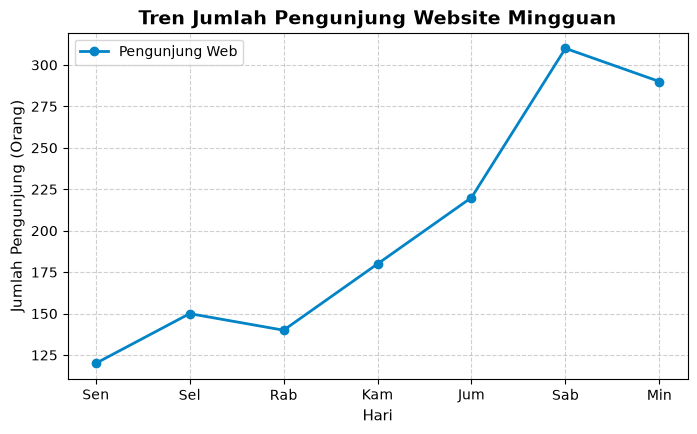

In [2]:
import matplotlib.pyplot as plt

# 1. Menyiapkan data sederhana
hari = ['Sen', 'Sel', 'Rab', 'Kam', 'Jum', 'Sab', 'Min']
pengunjung = [120, 150, 140, 180, 220, 310, 290]

# 2. Membuat kanvas gambar berukuran 8 x 4.5 inci
plt.figure(figsize=(8, 4.5))

# 3. Menggambar garis dengan penanda titik (marker)
plt.plot(hari, pengunjung, color='#0284c7', marker='o', linewidth=2, label='Pengunjung Web')

# 4. Menambahkan elemen pelengkap informasi
plt.title('Tren Jumlah Pengunjung Website Mingguan', fontsize=14, fontweight='bold')
plt.xlabel('Hari', fontsize=11)
plt.ylabel('Jumlah Pengunjung (Orang)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 5. Menampilkan grafik ke layar
plt.show()

## 3. Line Plot: Memantau Tren Berdasarkan Waktu (*Time Series*)

Diagram garis (*Line Plot*) adalah pilihan terbaik ketika Anda ingin memantau pergerakan suatu nilai dari waktu ke waktu (harian, bulanan, atau tahunan).

Mari kita visualisasikan tren penjualan e-commerce dari dua produk berbeda sepanjang semester pertama:

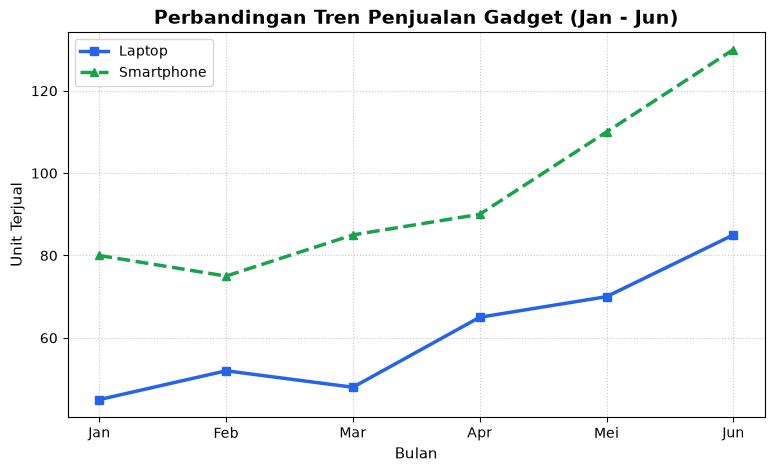

In [3]:
bulan = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun']
penjualan_laptop = [45, 52, 48, 65, 70, 85]
penjualan_smartphone = [80, 75, 85, 90, 110, 130]

plt.figure(figsize=(9, 5))

# Menggambar dua garis sekaligus pada satu bidang grafik
plt.plot(bulan, penjualan_laptop, color='#2563eb', marker='s', linewidth=2.5, label='Laptop')
plt.plot(bulan, penjualan_smartphone, color='#16a34a', marker='^', linewidth=2.5, linestyle='--', label='Smartphone')

plt.title('Perbandingan Tren Penjualan Gadget (Jan - Jun)', fontsize=14, fontweight='bold')
plt.xlabel('Bulan', fontsize=11)
plt.ylabel('Unit Terjual', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

## 4. Bar Plot: Membandingkan Nilai Antar Kategori

Jika data Anda berupa kategori diskrit (seperti nama divisi, jenis produk, atau nama kota), **Diagram Batang (*Bar Plot*)** jauh lebih tepat dibanding grafik garis karena data tidak memiliki kesinambungan waktu.

Tips profesional: Selalu tambahkan angka nilai (*data labels*) di atas setiap batang agar pembaca langsung tahu angka pastinya tanpa harus mengira-ngira ke sumbu Y.

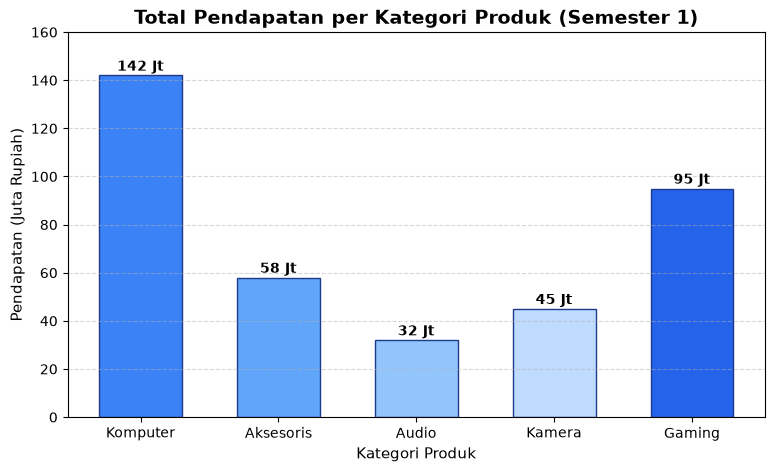

In [4]:
kategori = ['Komputer', 'Aksesoris', 'Audio', 'Kamera', 'Gaming']
total_omset = [142, 58, 32, 45, 95]  # Dalam juta rupiah
warna_batang = ['#3b82f6', '#60a5fa', '#93c5fd', '#bfdbfe', '#2563eb']

plt.figure(figsize=(9, 5))
batang = plt.bar(kategori, total_omset, color=warna_batang, edgecolor='#1e3a8a', width=0.6)

# Menambahkan label angka di atas setiap batang
for b in batang:
    tinggi = b.get_height()
    plt.text(b.get_x() + b.get_width() / 2, tinggi + 2, f"{int(tinggi)} Jt", ha='center', fontsize=10, fontweight='bold')

plt.title('Total Pendapatan per Kategori Produk (Semester 1)', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Produk', fontsize=11)
plt.ylabel('Pendapatan (Juta Rupiah)', fontsize=11)
plt.ylim(0, 160)  # Menambah ruang atas agar label angka muat
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## 5. Histogram: Melihat Distribusi dan Kepadatan Data

**Histogram** digunakan untuk melihat sebaran frekuensi dari suatu data angka kontinu. Misalnya, kita ingin tahu bagaimana sebaran skor ujian 200 siswa: apakah sebagian besar siswa dapat nilai sedang, atau condong banyak yang mendapat nilai rendah/tinggi?

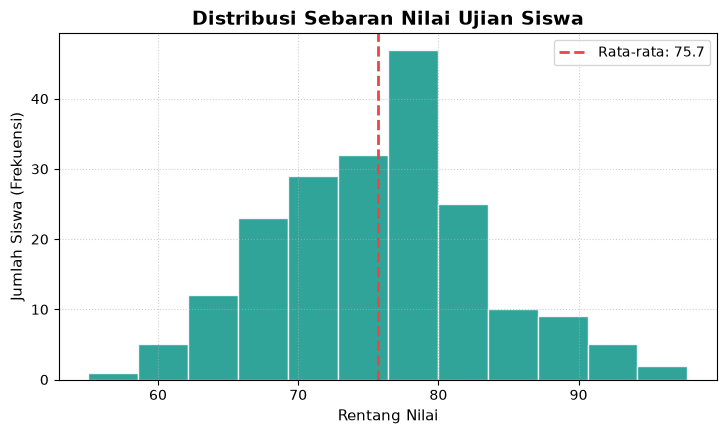

In [5]:
import numpy as np

# Menghasilkan 200 sampel nilai ujian (rata-rata 76, variasi sebaran 8)
np.random.seed(42)
nilai_ujian = np.random.normal(loc=76, scale=8, size=200)

plt.figure(figsize=(8.5, 4.5))
plt.hist(nilai_ujian, bins=12, color='#0d9488', edgecolor='white', alpha=0.85)

plt.axvline(np.mean(nilai_ujian), color='#ef4444', linestyle='dashed', linewidth=2, label=f'Rata-rata: {np.mean(nilai_ujian):.1f}')

plt.title('Distribusi Sebaran Nilai Ujian Siswa', fontsize=14, fontweight='bold')
plt.xlabel('Rentang Nilai', fontsize=11)
plt.ylabel('Jumlah Siswa (Frekuensi)', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## 6. Scatter Plot: Memeriksa Korelasi Hubungan 2 Variabel

**Diagram Tebar (*Scatter Plot*)** menampilkan titik-titik koordinat antara dua variabel numerik. Diagram ini sangat penting untuk menjawab pertanyaan hubungan kausalitas, misalnya:
> *"Apakah semakin besar biaya iklan digital yang dikeluarkan, jumlah pembeli yang datang juga meningkat sebanding?"*

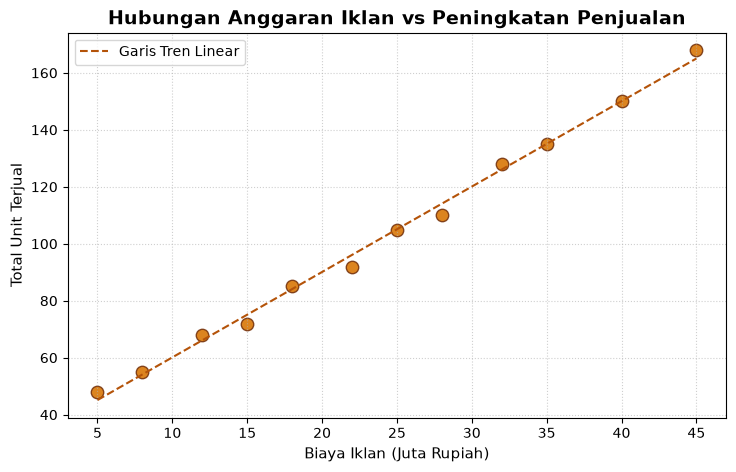

In [6]:
# Data anggaran iklan (juta rupiah) dan unit produk yang terjual di 12 toko
biaya_iklan = np.array([5, 8, 12, 15, 18, 22, 25, 28, 32, 35, 40, 45])
penjualan = np.array([48, 55, 68, 72, 85, 92, 105, 110, 128, 135, 150, 168])

plt.figure(figsize=(8.5, 5))
plt.scatter(biaya_iklan, penjualan, color='#d97706', s=80, edgecolors='#78350f', alpha=0.9)

# Menambahkan garis tren linear (regresi visual sederhana)
kemiringan, konstanta = np.polyfit(biaya_iklan, penjualan, 1)
plt.plot(biaya_iklan, kemiringan * biaya_iklan + konstanta, color='#b45309', linestyle='--', label='Garis Tren Linear')

plt.title('Hubungan Anggaran Iklan vs Peningkatan Penjualan', fontsize=14, fontweight='bold')
plt.xlabel('Biaya Iklan (Juta Rupiah)', fontsize=11)
plt.ylabel('Total Unit Terjual', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

## 7. Subplots: Menyusun Beberapa Grafik Berdampingan

Sering kali kita perlu membandingkan dua sudut pandang data sekaligus dalam satu laporan tanpa membuat dua file terpisah. Gunakan fungsi `plt.subplots(jumlah_baris, jumlah_kolom)`:

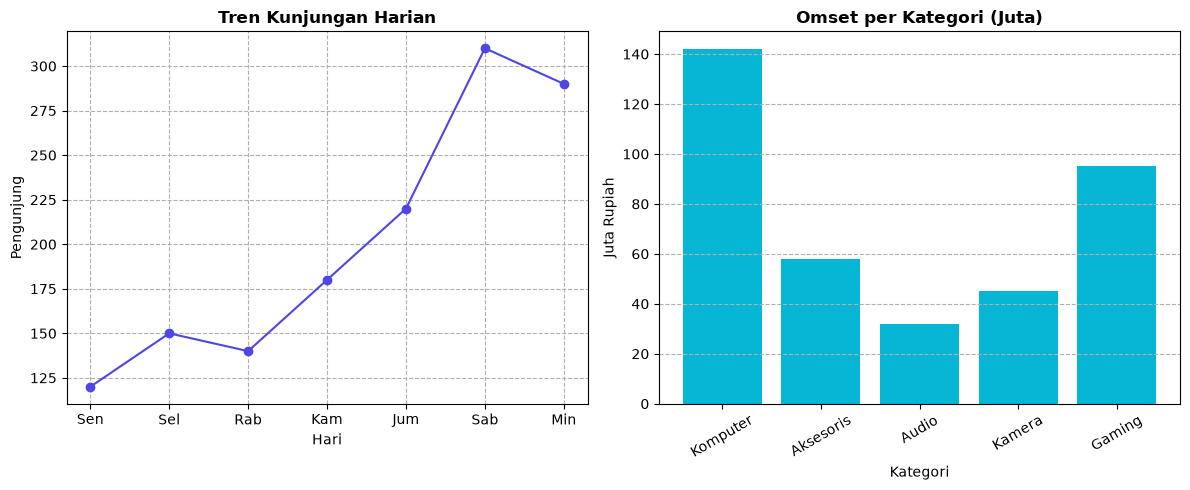

In [7]:
# Membuat 1 baris dengan 2 kolom grafik berdampingan
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Grafik 1 (Kiri): Tren Pengunjung
axes[0].plot(hari, pengunjung, color='#4f46e5', marker='o')
axes[0].set_title('Tren Kunjungan Harian', fontweight='bold')
axes[0].set_xlabel('Hari')
axes[0].set_ylabel('Pengunjung')
axes[0].grid(True, linestyle='--')

# Grafik 2 (Kanan): Komposisi Kategori
axes[1].bar(kategori, total_omset, color='#06b6d4')
axes[1].set_title('Omset per Kategori (Juta)', fontweight='bold')
axes[1].set_xlabel('Kategori')
axes[1].set_ylabel('Juta Rupiah')
axes[1].tick_params(axis='x', rotation=30)  # Memiringkan teks kategori agar tidak bertumpuk
axes[1].grid(axis='y', linestyle='--')

plt.tight_layout()  # Merapikan jarak antar grafik otomatis
plt.show()

## 8. Menyimpan Hasil Visualisasi ke File Gambar (`plt.savefig`)

Setelah membuat grafik yang bagus, Anda tentu ingin memasukkannya ke dalam slide presentasi PowerPoint atau dokumen laporan Word. Anda bisa menyimpannya secara otomatis menggunakan method `plt.savefig()` dengan resolusi tinggi (`dpi=300`):

✓ Grafik berhasil disimpan sebagai 'grafik_penjualan_laptop.png'


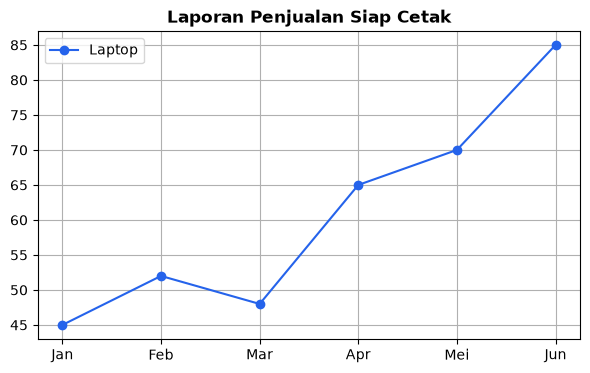

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(bulan, penjualan_laptop, color='#2563eb', marker='o', label='Laptop')
plt.title('Laporan Penjualan Siap Cetak', fontweight='bold')
plt.grid(True)
plt.legend()

# Menyimpan ke format PNG resolusi tajam dan memotong ruang kosong berlebih
plt.savefig('grafik_penjualan_laptop.png', dpi=300, bbox_inches='tight')
print("✓ Grafik berhasil disimpan sebagai 'grafik_penjualan_laptop.png'")

# Visualisasi Data Statistik dengan Seaborn

Setelah mempelajari Matplotlib di materi sebelumnya, pertanyaan yang sering muncul adalah:
> *"Kalau Matplotlib sudah bisa menggambar grafik apa saja, kenapa kita masih butuh Seaborn?"*

Perbedaannya terletak pada **level abstraksi** dan **kemudahan integrasi statistik**:
* **Matplotlib** bekerja di tingkat dasar (*low-level*). Anda harus mengatur setiap detail garis, warna, jarak batang, dan legenda secara manual. Ibaratnya, Anda merakit sepeda motor dari nol menggunakan baut dan obeng.
* **Seaborn** adalah pustaka visualisasi tingkat tinggi (*high-level*) yang dibangun tepat di atas Matplotlib. Seaborn dirancang khusus untuk bekerja langsung dengan **DataFrame Pandas**. Dengan hanya satu baris kode pendek, Seaborn otomatis menerapkan palet warna yang modern, mengelompokkan data berdasarkan kategori, dan menghitung estimasi statistik (seperti rata-rata, distribusi probabilitas, dan interval kepercayaan).

Singkatnya: Matplotlib memberikan **kebebasan kendali penuh**, sedangkan Seaborn memberikan **keindahan visual dan analisis statistik instan**.

## 1. Memasang Pustaka Seaborn

Pastikan pustaka Seaborn sudah terpasang di komputer Anda sebelum memulai:

In [1]:
! pip install seaborn

     -------------------------------------- 294.9/294.9 kB 2.3 MB/s eta 0:00:00



[notice] A new release of pip available: 22.2.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Setup Tema dan Menyiapkan Dataset Realistis

Seaborn memiliki fungsi `sns.set_theme(style="whitegrid")` yang otomatis mengubah tampilan grafik menjadi bersih, modern, dan profesional tanpa perlu mengatur font atau garis kisi satu per satu.

Mari kita siapkan contoh dataset transaksi toko daring berisi informasi kategori barang, harga, unit terjual, metode pembayaran, dan rating pembeli:

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Mengatur tema visual bersih bawaan Seaborn
sns.set_theme(style="whitegrid")

# Membuat dataset transaksi e-commerce
data_transaksi = pd.DataFrame({
    'Kategori': ['Komputer', 'Komputer', 'Aksesoris', 'Aksesoris', 'Audio', 'Audio', 'Komputer', 'Aksesoris', 'Audio', 'Komputer', 'Aksesoris', 'Audio'],
    'Harga_Ribu': [8500, 12000, 150, 450, 800, 1500, 9200, 250, 1100, 7800, 350, 1800],
    'Terjual': [15, 8, 85, 40, 30, 22, 12, 60, 25, 18, 50, 19],
    'Metode_Bayar': ['Transfer', 'QRIS', 'QRIS', 'Cash', 'QRIS', 'Transfer', 'Transfer', 'Cash', 'QRIS', 'Transfer', 'QRIS', 'Transfer'],
    'Rating': [4.8, 4.9, 4.5, 4.7, 4.3, 4.6, 4.7, 4.4, 4.5, 4.6, 4.8, 4.7]
})

print("Tabel Transaksi (5 Baris Pertama):")
print(data_transaksi.head())

Tabel Transaksi (5 Baris Pertama):
    Kategori  Harga_Ribu  Terjual Metode_Bayar  Rating
0   Komputer        8500       15     Transfer     4.8
1   Komputer       12000        8         QRIS     4.9
2  Aksesoris         150       85         QRIS     4.5
3  Aksesoris         450       40         Cash     4.7
4      Audio         800       30         QRIS     4.3


## 3. Kekuatan Parameter `hue`: Membedah Data Multi-Kategori

Salah satu fitur paling dicintai di Seaborn adalah parameter **`hue`**.

Dengan parameter `hue`, kita bisa memecah grafik batang per kategori berdasarkan dimensi tambahan (misalnya metode pembayaran) hanya dengan mengetik `hue='Metode_Bayar'`. Seaborn akan otomatis membuat warna berbeda dan menyusun legendanya secara rapi:

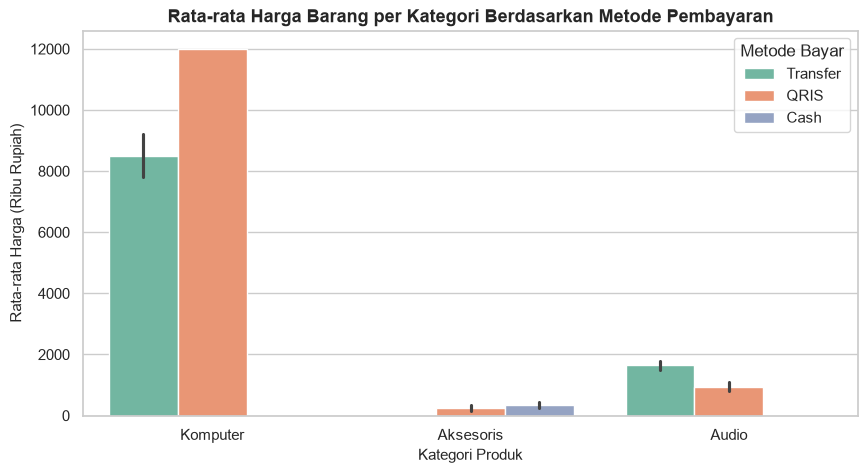

In [3]:
plt.figure(figsize=(10, 5))

# Barplot dengan pengelompokan warna berdasarkan Metode Pembayaran
sns.barplot(
    data=data_transaksi,
    x='Kategori',
    y='Harga_Ribu',
    hue='Metode_Bayar',
    palette='Set2'
)

plt.title('Rata-rata Harga Barang per Kategori Berdasarkan Metode Pembayaran', fontsize=13, fontweight='bold')
plt.xlabel('Kategori Produk', fontsize=11)
plt.ylabel('Rata-rata Harga (Ribu Rupiah)', fontsize=11)
plt.legend(title='Metode Bayar')
plt.show()

## 4. Histogram & Kurva Kepadatan Probabilitas (`kde=True`)

Saat menganalisis variabel kontinu (seperti skor rating atau usia pelanggan), kita ingin tahu apakah data tersebut condong ke arah kanan, kiri, atau simetris di tengah.

Dengan menambahkan opsi `kde=True` (*Kernel Density Estimate*), Seaborn akan menggambar kurva mulus di atas histogram untuk memperkirakan bentuk sebaran populasinya:

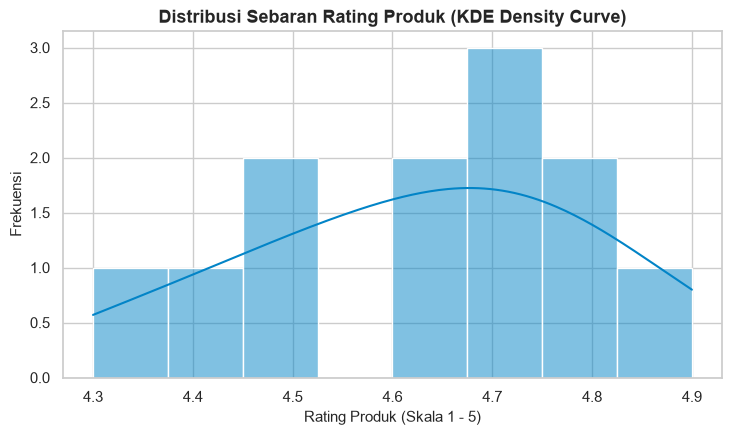

In [4]:
plt.figure(figsize=(8.5, 4.5))

# Histogram dengan estimasi kurva mulus KDE
sns.histplot(
    data=data_transaksi,
    x='Rating',
    kde=True,
    color='#0284c7',
    bins=8
)

plt.title('Distribusi Sebaran Rating Produk (KDE Density Curve)', fontsize=13, fontweight='bold')
plt.xlabel('Rating Produk (Skala 1 - 5)', fontsize=11)
plt.ylabel('Frekuensi', fontsize=11)
plt.show()

## 5. Boxplot: Memahami Distribusi Kuartil dan Mendeteksi Outlier

**Diagram Kotak Garis (*Boxplot*)** adalah salah satu alat paling penting bagi seorang praktisi data. Dari satu kotak kecil ini, kita bisa langsung membaca lima ringkasan statistik sekaligus:
1. **Garis tengah di dalam kotak**: Nilai Median (Q2 / kuartil tengah).
2. **Batas bawah & atas kotak**: Kuartil 1 (Q1 - 25% data) dan Kuartil 3 (Q3 - 75% data). Kotak ini merangkum 50% data utama Anda.
3. **Garis kumis (*whiskers*)**: Batas rentang data wajar terendah dan tertinggi.
4. **Titik-titik terisolasi di luar kumis**: **Outlier (Nilai Pencilan)**, yaitu data ekstrem yang jauh berbeda dari mayoritas populasi.

C:\Users\iputu\AppData\Local\Temp\ipykernel_16124\4147858169.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


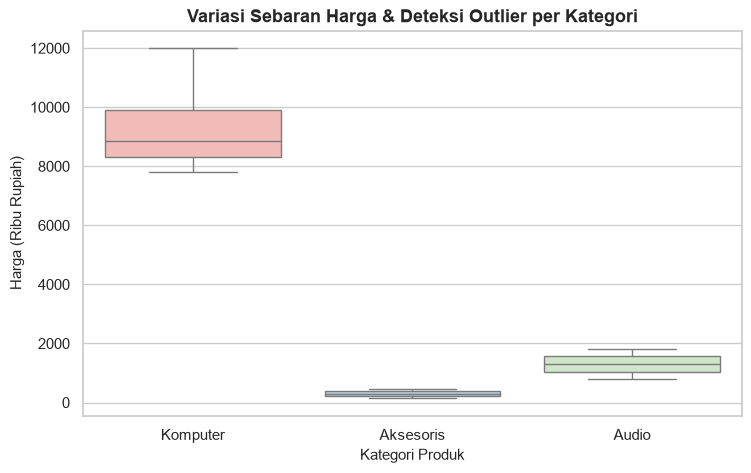

In [5]:
plt.figure(figsize=(8.5, 5))

# Boxplot variasi harga per kategori barang
sns.boxplot(
    data=data_transaksi,
    x='Kategori',
    y='Harga_Ribu',
    palette='Pastel1'
)

plt.title('Variasi Sebaran Harga & Deteksi Outlier per Kategori', fontsize=13, fontweight='bold')
plt.xlabel('Kategori Produk', fontsize=11)
plt.ylabel('Harga (Ribu Rupiah)', fontsize=11)
plt.show()

## 6. Scatter Plot Multi-Dimensi (Posisi, Warna, dan Ukuran)

Di Seaborn, kita bisa memvisualisasikan hingga **4 variabel sekaligus** dalam satu grafik sebar (*scatter plot*):
* Sumbu X: Harga Barang
* Sumbu Y: Jumlah Unit Terjual
* Warna (`hue`): Kategori Produk
* Ukuran Titik (`size`): Skor Rating

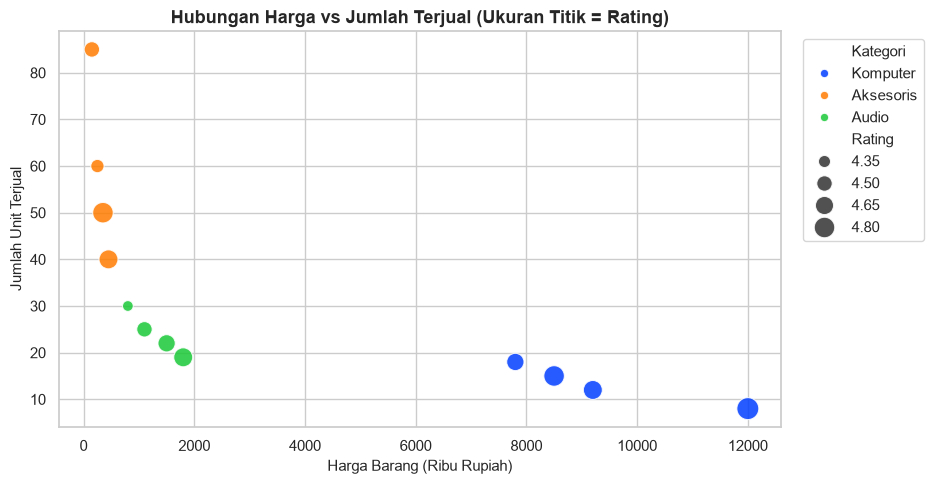

In [6]:
plt.figure(figsize=(9.5, 5))

sns.scatterplot(
    data=data_transaksi,
    x='Harga_Ribu',
    y='Terjual',
    hue='Kategori',
    size='Rating',
    sizes=(60, 250),
    palette='bright',
    alpha=0.85
)

plt.title('Hubungan Harga vs Jumlah Terjual (Ukuran Titik = Rating)', fontsize=13, fontweight='bold')
plt.xlabel('Harga Barang (Ribu Rupiah)', fontsize=11)
plt.ylabel('Jumlah Unit Terjual', fontsize=11)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')  # Meletakkan legenda di luar grafik
plt.tight_layout()
plt.show()

## 7. Heatmap Korelasi: Peta Panas Hubungan Antar Variabel Numerik

Dalam tahap **Analisis Data Eksploratif (EDA)** dan pembuatan model Machine Learning, langkah nomor satu yang hampir selalu dilakukan adalah memeriksa **matriks korelasi** antar seluruh kolom angka.

Korelasi berkisar antara `-1` (berbanding terbalik sempurna) hingga `+1` (berbanding lurus sempurna). Angka mendekati `0` berarti tidak ada hubungan linear.

Dengan fungsi `sns.heatmap()`, angka-angka korelasi ini diubah menjadi gradasi warna visual yang langsung menunjukkan variabel mana yang saling mempengaruhi:

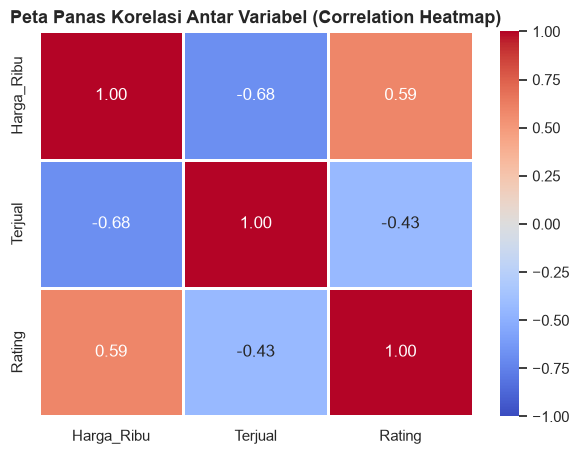

In [7]:
# Mengambil hanya kolom-kolom angka numerik
kolom_numerik = data_transaksi[['Harga_Ribu', 'Terjual', 'Rating']]

# Menghitung tabel matriks korelasi Pearson
matriks_korelasi = kolom_numerik.corr()

plt.figure(figsize=(7, 5))

# Menggambar heatmap dengan label angka (annot=True)
sns.heatmap(
    matriks_korelasi,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=1,
    vmin=-1,
    vmax=1
)

plt.title('Peta Panas Korelasi Antar Variabel (Correlation Heatmap)', fontsize=13, fontweight='bold')
plt.show()

# Teknik Impor & Ekspor Data (CSV, URL, Git, Google Drive, Excel, JSON)

Dalam proyek sains data di dunia industri, dataset jarang dibuat secara manual menggunakan kode, melainkan dimuat dari berbagai sumber penyimpanan: berkas lokal (CSV/Excel), tautan web langsung (URL), repositori Git, Google Drive (Google Colab), maupun API berbasis JSON. Modul ini membahas seluruh metode impor dan ekspor data paling esensial.

## 1. Membaca & Menulis Berkas CSV Lokal (`pd.read_csv` & `df.to_csv`)
CSV (*Comma Separated Values*) adalah format pertukaran data tabular yang paling umum digunakan dalam analisis data.

In [1]:
import pandas as pd

# 1. Membuat data sampel produk
df_produk = pd.DataFrame({
    'Kode': ['A01', 'A02', 'A03', 'A04'],
    'Produk': ['Laptop Pro', 'Mouse Wireless', 'Keyboard Mekanikal', 'Monitor 4K'],
    'Harga': [14500000, 250000, 850000, 4200000],
    'Stok': [12, 45, 28, 15]
})

# 2. Ekspor ke berkas CSV lokal (gunakan index=False agar nomor indeks tidak ikut tersimpan)
df_produk.to_csv('daftar_produk.csv', index=False)
print("Berkas 'daftar_produk.csv' berhasil disimpan!")

# 3. Membaca kembali berkas CSV
df_baca = pd.read_csv('daftar_produk.csv')
print("\nHasil Baca Berkas CSV:\n", df_baca)

Berkas 'daftar_produk.csv' berhasil disimpan!

Hasil Baca Berkas CSV:
   Kode              Produk     Harga  Stok
0  A01          Laptop Pro  14500000    12
1  A02      Mouse Wireless    250000    45
2  A03  Keyboard Mekanikal    850000    28
3  A04          Monitor 4K   4200000    15


### Parameter Penting pada `pd.read_csv`:
- `sep` atau `delimiter`: Menentukan pemisah kolom jika menggunakan titik koma (`;`) atau tab (`\t`).
- `usecols`: Hanya membaca kolom-kolom tertentu untuk menghemat penggunaan RAM.
- `nrows`: Membatasi jumlah baris yang dibaca (sangat berguna untuk mengintip sampel awal berkas raksasa berukuran gigabyte).
- `encoding`: Mengatur standar pengkodean karakter, misalnya `'utf-8'` atau `'latin1'`.

In [ ]:
# Contoh membaca hanya kolom 'Produk' dan 'Harga' serta membatasi 2 baris pertama
df_spesifik = pd.read_csv('daftar_produk.csv', usecols=['Produk', 'Harga'], nrows=2)
print("Baca Spesifik (Kolom Tertentu & Batas Baris):\n", df_spesifik)

Baca Spesifik (Kolom Tertentu & Batas Baris):
            Produk     Harga
0      Laptop Pro  14500000
1  Mouse Wireless    250000


## 2. Membaca Dataset Langsung dari URL Web (Online Dataset)
Fungsi `pd.read_csv` di Pandas dapat langsung menerima alamat tautan URL HTTP/HTTPS (seperti URL *raw* file di GitHub atau portal Open Data), sehingga Anda tidak perlu mengunduh berkas secara manual terlebih dahulu ke komputer.

In [2]:
# Membaca dataset publik langsung dari GitHub Raw URL
url_dataset = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv'
df_online = pd.read_csv(url_dataset)

print(f"Dataset berhasil dimuat dari URL! Dimensi: {df_online.shape[0]} baris, {df_online.shape[1]} kolom.")
print("\n5 Baris Pertama:\n", df_online.head())

Dataset berhasil dimuat dari URL! Dimensi: 150 baris, 5 kolom.

5 Baris Pertama:
    sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


## 3. Mengunduh & Mengimpor Data Menggunakan Git (`git clone`)
Jika proyek riset atau tim Anda menyimpan kumpulan dataset, gambar, dan skrip pada repositori GitHub/GitLab, Anda dapat menarik seluruh repositori ke lingkungan kerja menggunakan perintah `!git clone`.

In [3]:
! git clone https://github.com/mwaskom/seaborn-data


df_repo = pd.read_csv('seaborn-data/titanic.csv')
print(f"Dataset berhasil dimuat")

Cloning into 'seaborn-data'...
remote: Enumerating objects: 208, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 208 (delta 46), reused 38 (delta 38), pack-reused 148 (from 2)
Receiving objects: 100% (208/208), 7.29 MiB | 26.48 MiB/s, done.
Resolving deltas: 100% (86/86), done.
Dataset berhasil dimuat


## 4. Menghubungkan & Mengakses Data dari Google Drive (Google Colab Workflow)
Pada lingkungan **Google Colab**, penyimpanan lokal bersifat sementara (*ephemeral*) dan akan hilang saat runtime di-restart. Untuk menyimpan atau memuat dataset berukuran besar secara persisten, praktisi data mengaitkan (*mount*) akun **Google Drive** ke Google Colab.

### Langkah-Langkah Integrasi Google Drive di Colab:
1. Hubungkan Google Drive dengan modul bawaan `google.colab`.
2. Berikan izin akses saat muncul jendela verifikasi akun Google.
3. Seluruh folder dan berkas di Google Drive Anda akan tersedia di jalur direktori `/content/drive/MyDrive/`.

In [5]:
# Skrip khusus lingkungan Google Colab:
from google.colab import drive
drive.mount('/content/drive')

# Jalur akses dataset yang tersimpan di Google Drive:
path_file = '/content/drive/MyDrive/Pelatihan SPSS Potik/kapal_titanic.csv'
df_drive = pd.read_csv(path_file)
print(df_drive.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   survived  pclass     sex   age  sibsp  parch     fare embarked deck
0         0       3    male  22.0      1      0   7.2500        S  NaN
1         1       1  female  38.0      1      0  71.2833        C    C
2         1       3  female  26.0      0      0   7.9250        S  NaN
3         1       1  female  35.0      1      0  53.1000        S    C
4         0       3    male  35.0      0      0   8.0500        S  NaN


## 5. Membaca & Mengekspor Format Microsoft Excel (`.xlsx`)
Selain CSV, berkas spreadsheet Microsoft Excel (`.xlsx`) sangat banyak digunakan dalam laporan bisnis. Untuk membaca dan menulis format Excel, Pandas membutuhkan modul pihak ketiga bernama **openpyxl** (`pip install openpyxl`).

Gunakan fungsi `pd.read_excel()` untuk membaca dan method `df.to_excel()` untuk mengekspor.

In [7]:
! pip install openpyxl


df_produk.to_excel('laporan_inventaris.xlsx', sheet_name='Ringkasan_Stok', index=False)

# Contoh membaca sheet tertentu dari berkas Excel:
df_excel = pd.read_excel('laporan_inventaris.xlsx', sheet_name='Ringkasan_Stok')

print("Fungsi Ekspor Excel: df.to_excel('laporan.xlsx', sheet_name='Sheet1', index=False)")
print("Fungsi Baca Excel  : pd.read_excel('laporan.xlsx', sheet_name='Sheet1')")

Fungsi Ekspor Excel: df.to_excel('laporan.xlsx', sheet_name='Sheet1', index=False)
Fungsi Baca Excel  : pd.read_excel('laporan.xlsx', sheet_name='Sheet1')


## 6. Membaca & Mengekspor Format JSON (`pd.read_json` & `df.to_json`)
JSON (*JavaScript Object Notation*) adalah format transmisi standar untuk integrasi API dan aplikasi web modern.

In [6]:
# 1. Ekspor DataFrame ke berkas JSON (orient='records' menyusun data per baris objek)
df_produk.to_json('daftar_produk.json', orient='records', indent=2)
print("Berkas 'daftar_produk.json' berhasil diekspor!")

# 2. Membaca kembali dari berkas JSON
df_json = pd.read_json('daftar_produk.json')
print("\nHasil Baca Berkas JSON:\n", df_json)

Berkas 'daftar_produk.json' berhasil diekspor!

Hasil Baca Berkas JSON:
   Kode              Produk     Harga  Stok
0  A01          Laptop Pro  14500000    12
1  A02      Mouse Wireless    250000    45
2  A03  Keyboard Mekanikal    850000    28
3  A04          Monitor 4K   4200000    15


## 7. Rangkuman Tabel Fungsi Impor & Ekspor Data

| Sumber / Format | Fungsi Membaca (*Import*) | Fungsi Menyimpan (*Export*) | Kebutuhan Tambahan / Parameter Kunci |
| :--- | :--- | :--- | :--- |
| **CSV Lokal** | `pd.read_csv('file.csv')` | `df.to_csv('file.csv', index=False)` | `sep=';'`, `encoding='utf-8'`, `usecols` |
| **URL Web / GitHub** | `pd.read_csv('https://...')` | - | Mendukung protokol HTTP/HTTPS langsung |
| **Git Clone** | `!git clone <url_repo>` lalu `pd.read_csv(...)` | `git push` via CLI | Menarik seluruh folder repositori data |
| **Google Drive** | `from google.colab import drive` + `drive.mount('/content/drive')` | `df.to_csv('/content/drive/MyDrive/...')` | Khusus Google Colab untuk persistensi cloud |
| **Excel (.xlsx)** | `pd.read_excel('file.xlsx', sheet_name=...)` | `df.to_excel('file.xlsx', index=False)` | Memerlukan pustaka `openpyxl` |
| **JSON** | `pd.read_json('file.json')` | `df.to_json('file.json', orient='records')` | Format standar API web dan NoSQL |

# Tugas Praktik: Mini Proyek Analisis & Visualisasi Produk (Tantangan Mandiri)

### Instruksi Tantangan:
Tugas integrasi Bab 2 ini dirancang untuk **menguji daya nalar dan pemahaman mandiri** Anda setelah mempelajari ekosistem paket Python: **Pip**, **NumPy**, **Pandas**, **Matplotlib**, dan **Seaborn**.

> 🧠 **Tantangan Anda:** Alih-alih hanya menjalankan kode yang sudah siap pakai, Anda diminta **memikirkan logika dan melengkapi bagian-bagian kode yang masih rumpang (`_______`)**.

Silakan klik tombol **Buka di Google Colab** atau unduh file `.ipynb` ini untuk mengisi dan menguji langsung program Anda.

## Tolok Ukur Hasil (Expected Output)
Sebelum mulai menulis kode, cermati target output teks dan grafik di bawah ini. Kode yang Anda lengkapi harus mampu menghasilkan komputasi dan visualisasi serupa:

=== TARGET OUTPUT SOAL 1 & 2 ===
   Kode              Produk     Harga  Stok  Total_Nilai
0  A01          Laptop Pro  14500000    12    174000000
1  A02      Mouse Wireless    250000    45     11250000
2  A03  Keyboard Mekanikal    850000    28     23800000
3  A04          Monitor 4K   4200000    15     63000000

=== TARGET RINGKASAN SAINTIFIK (NUMPY) ===
Total Nilai Aset Inventaris : Rp 272,050,000
Rata-rata Harga Produk     : Rp 4,950,000
Rata-rata Stok Unit         : 25.0 unit


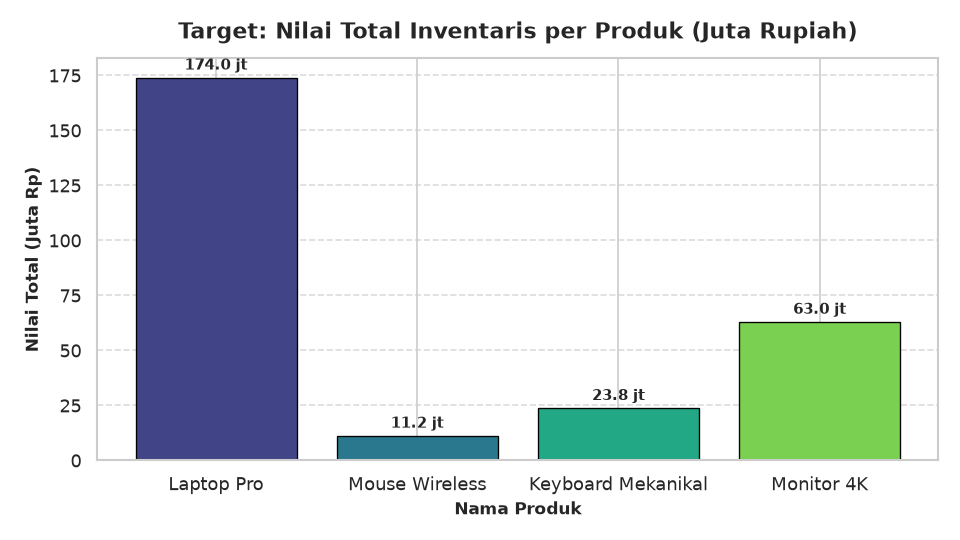

In [ ]:
# [Target Output Visualisasi & Komputasi]
# Perhatikan acuan diagram batang dan output konsol di bawah ini sebelum Anda melengkapi soal-soal berikut.

---
### Soal 1: Membaca Dataset dengan Pandas
**Instruksi:** Panggil fungsi Pandas yang tepat untuk membaca file `daftar_produk.csv` pada bagian kosong `_______`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TODO 1: Ganti '_______' dengan nama method Pandas untuk membaca file CSV
df = pd._______('daftar_produk.csv')

print("Dataset Berhasil Dimuat:")
print(df)
print(f"\nDimensi Data: {df.shape[0]} baris, {df.shape[1]} kolom")

---
### Soal 2: Menghitung Kolom Vektor & Statistik Agregasi NumPy
**Instruksi:**
1. Lengkapi kalkulasi vektor untuk kolom baru `Total_Nilai` yang merupakan perkalian `Harga` dan `Stok`.
2. Gunakan fungsi statistik NumPy (`np.sum` dan `np.mean`) pada bagian `_______` untuk menghitung total aset dan rata-rata.

In [ ]:
# TODO 2a: Lengkapi perkalian kolom vektor (Harga dikali Stok)
df['Total_Nilai'] = df['_______'] * df['_______']

# TODO 2b: Lengkapi fungsi statistik NumPy yang tepat (sum / mean)
total_aset = np._______(df['Total_Nilai'])
rata_harga = np._______(df['Harga'])
rata_stok  = np._______(df['Stok'])

print("Hasil Penambahan Kolom Baru (Total_Nilai):")
print(df[['Kode', 'Produk', 'Harga', 'Stok', 'Total_Nilai']])
print("\n=== Ringkasan Statistik Saintifik (NumPy) ===")
print(f"Total Nilai Aset Inventaris : Rp {total_aset:,.0f}")
print(f"Rata-rata Harga Produk     : Rp {rata_harga:,.0f}")
print(f"Rata-rata Stok Unit         : {rata_stok:.1f} unit")

---
### Soal 3: Visualisasi Diagram Batang (Bar Chart)
**Instruksi:** Masukkan kolom kategori produk untuk sumbu X dan total nilai stok untuk sumbu Y, lalu berikan label sumbu yang informatif pada bagian `_______`.

In [ ]:
# Mengatur tema grafik modern
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(8, 4.5))

# TODO 3a: Tentukan kolom sumbu X (kategori produk) dan sumbu Y (total nilai dalam jutaan)
palette = sns.color_palette("viridis", len(df))
bars = ax.bar(df['_______'], df['_______'] / 1_000_000, color=palette, edgecolor='black', linewidth=0.8)

# TODO 3b: Berikan label nama sumbu yang deskriptif
ax.set_title("Nilai Total Inventaris per Produk (Juta Rupiah)", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("_______", fontsize=10, fontweight='bold')
ax.set_ylabel("_______", fontsize=10, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Menambahkan label nilai di atas batang
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 2, f"{yval:.1f} jt", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

---
### Soal 4: Ekspor DataFrame ke File CSV Bersih
**Instruksi:** Lengkapi method ekspor DataFrame ke file `laporan_inventaris_selesai.csv` tanpa mengikutsertakan indeks bawaan (`index=False`).

In [ ]:
# TODO 4: Lengkapi fungsi ekspor file CSV dan parameter index
output_file = 'laporan_inventaris_selesai.csv'
df._______(output_file, index=_______)

print(f"Laporan berhasil diekspor ke: {output_file}")
print("Selamat, Anda telah berhasil menyelesaikan seluruh tantangan mandiri Bab 2!")